In [1]:
#DATA VALIDATION AND CLEANING
import pandas as pd
import scipy.stats as st
from statsmodels.stats.proportion import confint_proportions_2indep
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from cycler import cycler
data = pd.read_csv("marketing_AB.csv")

print(data.isnull().sum())
print(data['user id'].duplicated().sum())
print(data.describe())
print(data.info())
data.drop('Unnamed: 0', axis=1, inplace=True)



Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64
0
          Unnamed: 0       user id      total ads  most ads hour
count  588101.000000  5.881010e+05  588101.000000  588101.000000
mean   294050.000000  1.310692e+06      24.820876      14.469061
std    169770.279668  2.022260e+05      43.715181       4.834634
min         0.000000  9.000000e+05       1.000000       0.000000
25%    147025.000000  1.143190e+06       4.000000      11.000000
50%    294050.000000  1.313725e+06      13.000000      14.000000
75%    441075.000000  1.484088e+06      27.000000      18.000000
max    588100.000000  1.654483e+06    2065.000000      23.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        58810

In [2]:
#DESCRIPTIVE STATS PER GROUP
test_grp_total = data.groupby('test group')['user id'].count()

conversion_rate = data.groupby('test group')['converted'].mean()


print(test_grp_total.reset_index().rename(columns={'test group': 'Group', 'user id': 'Size'}))
print(f'Ad Conversion Rate: {round((conversion_rate.ad * 100.0), 2)}%')
print(f'PSA Conversion Rate: {round((conversion_rate.psa * 100.0), 2)}%')



  Group    Size
0    ad  564577
1   psa   23524
Ad Conversion Rate: 2.55%
PSA Conversion Rate: 1.79%


In [ ]:
#STATISTICAL TEST
contingency_table = pd.crosstab(data['converted'], data['test group'])
chi_2, p_value, _, _ = st.contingency.chi2_contingency(contingency_table)
print(contingency_table, '\n')
print(f'Chi-Square: {chi_2}')
print(f'P-Value: {p_value}')

if p_value < 0.05:
    print("Reject null hypothesis. There is a significant difference")
else:
    print("Fail to reject null hypothesis. There is no significant difference")

cramers_v = st.contingency.association(contingency_table, method="cramer")
print(f'Cramer\'s V: {round(cramers_v, 4)}')

if cramers_v == 0:
    print('No Association')
elif 0 < cramers_v <= 0.1:
    print('Weak Association')
elif 0.1 < cramers_v <= 0.3:
    print('Moderate Association')
elif 0.3 < cramers_v <= 0.5:
    print('Strong Association')
else:
    print('Very Strong Association')

conversion_count = data.groupby(['test group', 'converted'])['user id'].count()
confidence_interval = confint_proportions_2indep(count1=conversion_count['ad', True], nobs1=test_grp_total.ad,
                                                 count2=conversion_count['psa', True], nobs2=test_grp_total.psa,
                                                 method='wald', compare='diff')
print(f'Confidence Interval: ({confidence_interval[0] * 100.0:.2f}%, {confidence_interval[1] * 100.0:.2f}%)')

test group      ad    psa
converted                
False       550154  23104
True         14423    420 

Chi-Square: 54.005823883685245
P-Value: 1.9989623063390075e-13
Reject null hypothesis. There is a significant difference
Cramer's V: 0.0096
Weak Association
Confidence Interval: (0.60%, 0.94%)
test group  converted
ad          False        550154
            True          14423
psa         False         23104
            True            420
Name: user id, dtype: int64


  Exposure Level    Size
0   Low Exposure  587909
1   Mid Exposure     184
2  High Exposure       8 

  Exposure Level  Conversion Rate
0   Low Exposure             2.52
1   Mid Exposure            16.85
2  High Exposure            50.00
          Day Group  Conversion Rate
0      Friday    ad             2.25
1      Friday   psa             1.63
2      Monday    ad             3.32
3      Monday   psa             2.26
4    Saturday    ad             2.13
5    Saturday   psa             1.40
6      Sunday    ad             2.46
7      Sunday   psa             2.06
8    Thursday    ad             2.16
9    Thursday   psa             2.02
10    Tuesday    ad             3.04
11    Tuesday   psa             1.44
12  Wednesday    ad             2.54
13  Wednesday   psa             1.58


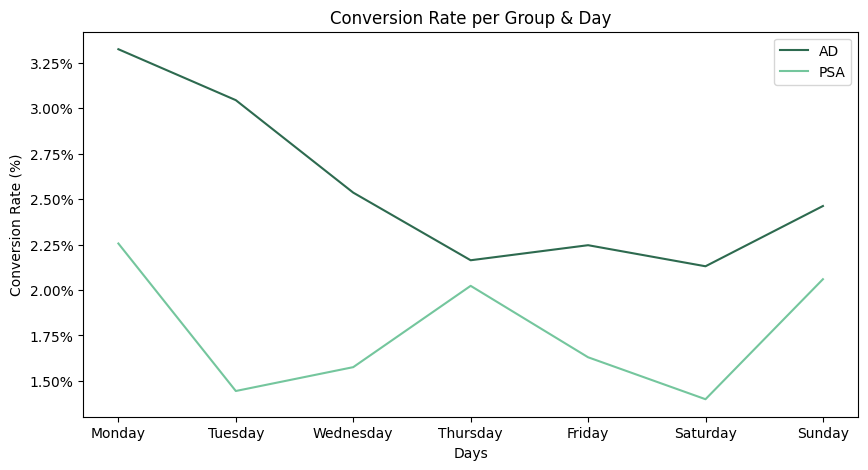

    Hours  Conversion Rate
0       0             1.84
1       1             1.29
2       2             0.73
3       3             1.05
4       4             1.52
5       5             2.09
6       6             2.22
7       7             1.81
8       8             1.95
9       9             1.92
10     10             2.15
11     11             2.21
12     12             2.38
13     13             2.47
14     14             2.81
15     15             2.97
16     16             3.08
17     17             2.82
18     18             2.74
19     19             2.67
20     20             2.98
21     21             2.89
22     22             2.61
23     23             2.27


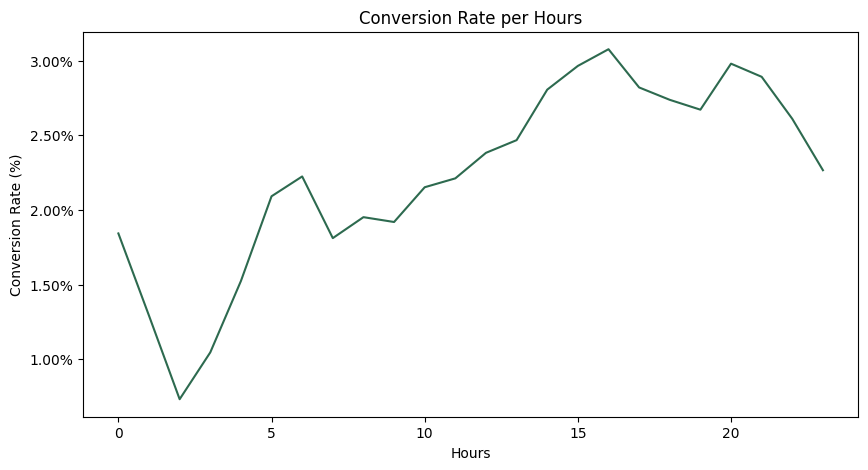

In [4]:
#SUPPORTING QUESTIONS

#What is the relationship between ad exposure volume and conversion likelihood?
data['exposure volume'] = pd.cut(data['total ads'], bins=3, labels=['Low Exposure', 'Mid Exposure', 'High Exposure'])
exposure_count = data.groupby('exposure volume', observed=True)['user id'].count().reset_index().rename(columns={'exposure volume': 'Exposure Level', 'user id': 'Size'})
exposure_and_likelihood = data.groupby('exposure volume', observed=True)['converted'].mean()
print(exposure_count, '\n') #High Exposure size is too small to have a reliable conversion rate
print(round((exposure_and_likelihood * 100.0), 2).reset_index().rename(columns={'exposure volume': 'Exposure Level', 'converted': 'Conversion Rate'}))

#Does certain days show higher conversion rates, and does that differ between the two groups?
days_conversion_rate = data.groupby(['most ads day', 'test group'], observed=True)['converted'].mean()
print(round((days_conversion_rate * 100.0), 2).reset_index().rename(columns={'most ads day': 'Day', 'test group': 'Group', 'converted': 'Conversion Rate'}))

#PLOTTING
days_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
x = range(len(days_labels))
ad_line = days_conversion_rate.xs('ad', level='test group').reindex(days_labels)
psa_line = days_conversion_rate.xs('psa', level='test group').reindex(days_labels)

plt.figure(figsize=(10, 5))
plt.rc('axes', prop_cycle=cycler('color', ['#2D6A4F', '#74C69D']))
plt.plot(x, ad_line)
plt.plot(x, psa_line)

plt.legend(['AD', 'PSA'])
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y * 100:.2f}%'))
plt.xticks(x, days_labels)
plt.xlabel('Days')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate per Group & Day')
plt.show()


#Does the hour of peak ad exposure correlates with higher conversion rates?
hours_conversion_rate = data.groupby(['most ads hour'], observed=True)['converted'].mean()
print(round((hours_conversion_rate * 100.0), 2).reset_index().rename(columns={'most ads hour': 'Hours', 'converted': 'Conversion Rate'}))

#PLOTTING
x = range(len(hours_conversion_rate))

plt.figure(figsize=(10, 5))
plt.rc('axes', prop_cycle=cycler('color', ['#2D6A4F', '#74C69D']))
plt.plot(x, hours_conversion_rate)

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y * 100:.2f}%'))
plt.xlabel('Hours')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate per Hours')
plt.show()

In [6]:
# EXPORTING FOR POWER BI
test_grp_total_df = data.groupby('test group')['user id'].count().reset_index()
conversion_rate_df = data.groupby('test group')['converted'].mean().reset_index()
test_grp_total_df.to_csv('export/test_grp_total.csv', index=False)
conversion_rate_df.to_csv('export/conversion_rate.csv', index=False)


conversion_count_df = data.groupby(['test group', 'converted'])['user id'].count().reset_index()
conversion_count_df.to_csv('export/conversion_count.csv', index=False)


exposure_count_df = data.groupby('exposure volume', observed=True)['user id'].count().reset_index().rename(columns={'exposure volume': 'Exposure Level', 'user id': 'Size'})
exposure_and_likelihood_df = data.groupby('exposure volume', observed=True)['converted'].mean().reset_index()
days_conversion_rate_df = data.groupby(['most ads day', 'test group'], observed=True)['converted'].mean().reset_index()
hours_conversion_rate_df = data.groupby(['most ads hour'], observed=True)['converted'].mean().reset_index()

exposure_count_df.to_csv('export/exposure_count.csv', index=False)
exposure_and_likelihood_df.to_csv('export/exposure_and_likelihood.csv', index=False)
days_conversion_rate_df.to_csv('export/days_conversion_rate.csv', index=False)
hours_conversion_rate_df.to_csv('export/hours_conversion_rate.csv', index=False)